<a href="https://www.kaggle.com/code/lalit7881/ai-the-future-of-work?scriptVersionId=301859788" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/omarshahrukh/msft-stock-data-19862026/MSFT_Stock_Data_1986_2026.csv


## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/omarshahrukh/msft-stock-data-19862026/MSFT_Stock_Data_1986_2026.csv")

In [3]:
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return_Pct,Daily_Range,MA_20,MA_50,...,Year,Month,Quarter,Day_of_Week,RSI_14,MACD,MACD_Signal,BB_Upper,BB_Lower,BB_Middle
0,1986-03-13,0.0593,0.0619,0.0540,0.0540,1031788800,NaN,0.0079,NaN,NaN,...,1986,3,1,Thursday,NaN,0.0000,0.0000,NaN,NaN,NaN
1,1986-03-14,0.0614,0.0624,0.0593,0.0593,308160000,3.5413,0.0031,NaN,NaN,...,1986,3,1,Friday,NaN,0.0002,0.0000,NaN,NaN,NaN
2,1986-03-17,0.0624,0.0630,0.0614,0.0614,133171200,1.6287,0.0016,NaN,NaN,...,1986,3,1,Monday,NaN,0.0004,0.0001,NaN,NaN,NaN
3,1986-03-18,0.0608,0.0630,0.0603,0.0624,67766400,-2.5641,0.0027,NaN,NaN,...,1986,3,1,Tuesday,NaN,0.0004,0.0002,NaN,NaN,NaN
4,1986-03-19,0.0598,0.0614,0.0593,0.0608,47894400,-1.6447,0.0021,NaN,NaN,...,1986,3,1,Wednesday,NaN,0.0003,0.0002,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10072 entries, 0 to 10071
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              10072 non-null  object 
 1   Close             10072 non-null  float64
 2   High              10072 non-null  float64
 3   Low               10072 non-null  float64
 4   Open              10072 non-null  float64
 5   Volume            10072 non-null  int64  
 6   Daily_Return_Pct  10071 non-null  float64
 7   Daily_Range       10072 non-null  float64
 8   MA_20             10053 non-null  float64
 9   MA_50             10023 non-null  float64
 10  MA_200            9873 non-null   float64
 11  Volatility_20D    10052 non-null  float64
 12  Volume_MA_20      10053 non-null  float64
 13  Year              10072 non-null  int64  
 14  Month             10072 non-null  int64  
 15  Quarter           10072 non-null  int64  
 16  Day_of_Week       10072 non-null  object

In [5]:
df.describe()

,Close,High,Low,Open,Volume,Daily_Return_Pct,Daily_Range,MA_20,MA_50,MA_200,...,Volume_MA_20,Year,Month,Quarter,RSI_14,MACD,MACD_Signal,BB_Upper,BB_Lower,BB_Middle
count,10072.000000,10072.000000,10072.000000,10072.000000,1.007200e+04,10071.000000,10072.000000,10053.000000,10023.000000,9873.000000,...,1.005300e+04,10072.000000,10072.000000,10072.000000,10058.000000,10072.000000,10072.000000,10053.000000,10053.000000,10053.000000
mean,67.782699,68.427052,67.086722,67.771582,5.545278e+07,0.109794,1.340330,67.532937,67.089985,64.385520,...,5.535798e+07,2005.657863,6.542693,2.514098,54.092058,0.291481,0.296827,71.016428,64.049446,67.532937
std,116.776138,117.795773,115.667711,116.775770,3.800392e+07,2.091660,2.499288,116.364932,115.572801,109.817748,...,2.453783e+07,11.546640,3.429730,1.114977,16.220261,2.238994,2.104043,122.051994,110.771161,116.364932
min,0.055000,0.056100,0.054000,0.054000,2.304000e+06,-30.109500,0.000500,0.058600,0.061700,0.071100,...,1.157184e+07,1986.000000,1.000000,1.000000,1.540000,-18.848200,-17.681400,0.062100,0.053500,0.058600
25%,3.809200,3.847200,3.753800,3.806800,3.028452e+07,-0.906350,0.099800,3.776500,3.849200,4.193200,...,3.362750e+07,1996.000000,4.000000,2.000000,42.460000,-0.060925,-0.049125,4.053400,3.578500,3.776500
50%,19.460800,19.685450,19.254300,19.434150,4.870160e+07,0.038300,0.390450,19.507500,19.379600,19.579600,...,5.550851e+07,2006.000000,7.000000,3.000000,54.390000,0.025200,0.025300,20.601300,18.407300,19.507500
75%,46.182825,46.601100,45.665300,46.078725,6.938785e+07,1.107850,0.927350,45.823800,46.180650,44.319100,...,7.049952e+07,2016.000000,10.000000,4.000000,65.940000,0.357650,0.347325,48.292700,43.468800,45.823800
max,539.825300,552.242000,538.530700,552.023200,1.031789e+09,19.565100,39.825200,519.582900,512.314600,485.279800,...,1.654178e+08,2026.000000,12.000000,4.000000,99.110000,18.596000,16.702400,542.828000,506.282700,519.582900


In [6]:
df.isnull().sum()

Date                  0
Close                 0
High                  0
Low                   0
Open                  0
Volume                0
Daily_Return_Pct      1
Daily_Range           0
MA_20                19
MA_50                49
MA_200              199
Volatility_20D       20
Volume_MA_20         19
Year                  0
Month                 0
Quarter               0
Day_of_Week           0
RSI_14               14
MACD                  0
MACD_Signal           0
BB_Upper             19
BB_Lower             19
BB_Middle            19
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

Date                 object
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
Daily_Return_Pct    float64
Daily_Range         float64
MA_20               float64
MA_50               float64
MA_200              float64
Volatility_20D      float64
Volume_MA_20        float64
Year                  int64
Month                 int64
Quarter               int64
Day_of_Week          object
RSI_14              float64
MACD                float64
MACD_Signal         float64
BB_Upper            float64
BB_Lower            float64
BB_Middle           float64
dtype: object

In [9]:
df.shape

(10072, 23)

In [10]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return_Pct',
       'Daily_Range', 'MA_20', 'MA_50', 'MA_200', 'Volatility_20D',
       'Volume_MA_20', 'Year', 'Month', 'Quarter', 'Day_of_Week', 'RSI_14',
       'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower', 'BB_Middle'],
      dtype='object')

In [11]:
df.nunique()

Date                10072
Close                7923
High                 7707
Low                  7724
Open                 7803
Volume               9877
Daily_Return_Pct     8965
Daily_Range          4973
MA_20                9553
MA_50                9543
MA_200               9455
Volatility_20D       8350
Volume_MA_20        10032
Year                   41
Month                  12
Quarter                 4
Day_of_Week             5
RSI_14               5006
MACD                 6989
MACD_Signal          6850
BB_Upper             9574
BB_Lower             9517
BB_Middle            9553
dtype: int64

## EDA

In [12]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Set style
sns.set(style="whitegrid")

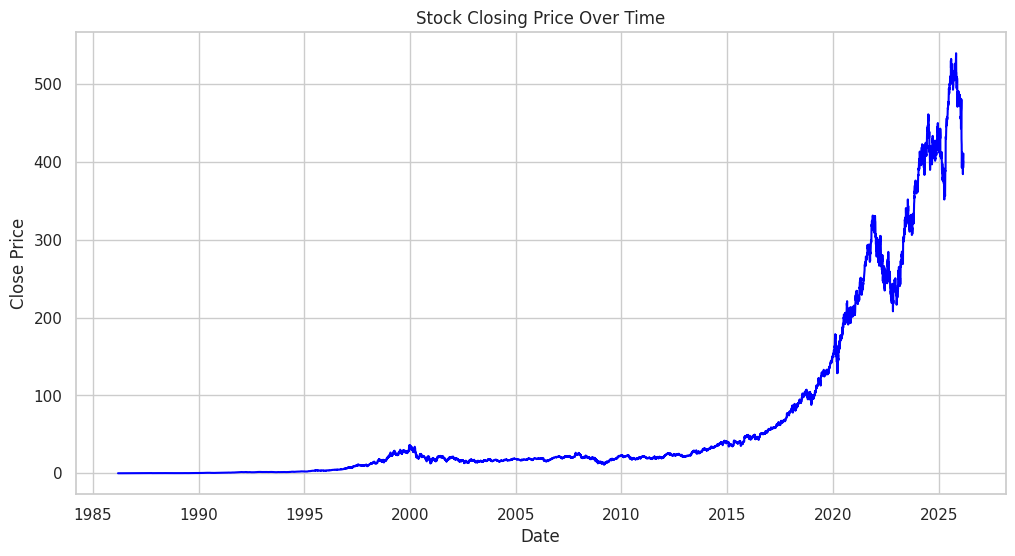

In [13]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], color='blue')
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

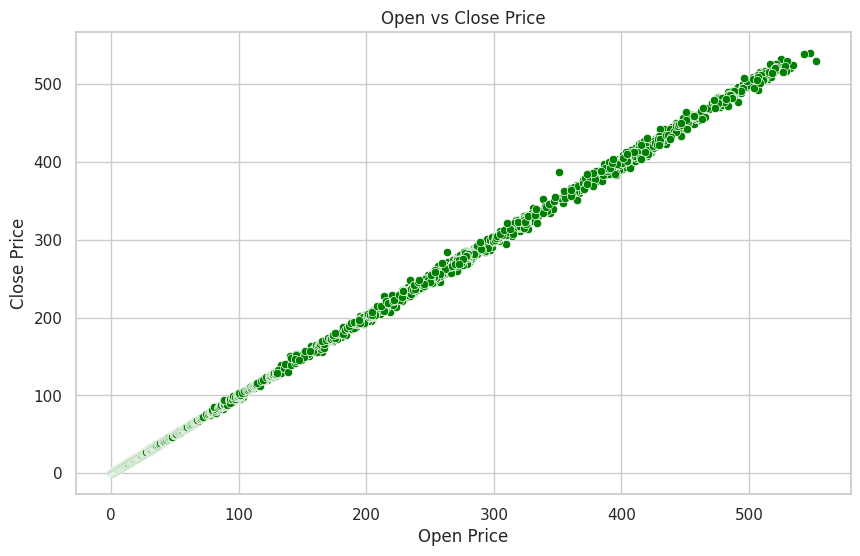

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Open'], y=df['Close'], color='green')
plt.title("Open vs Close Price")
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.show()

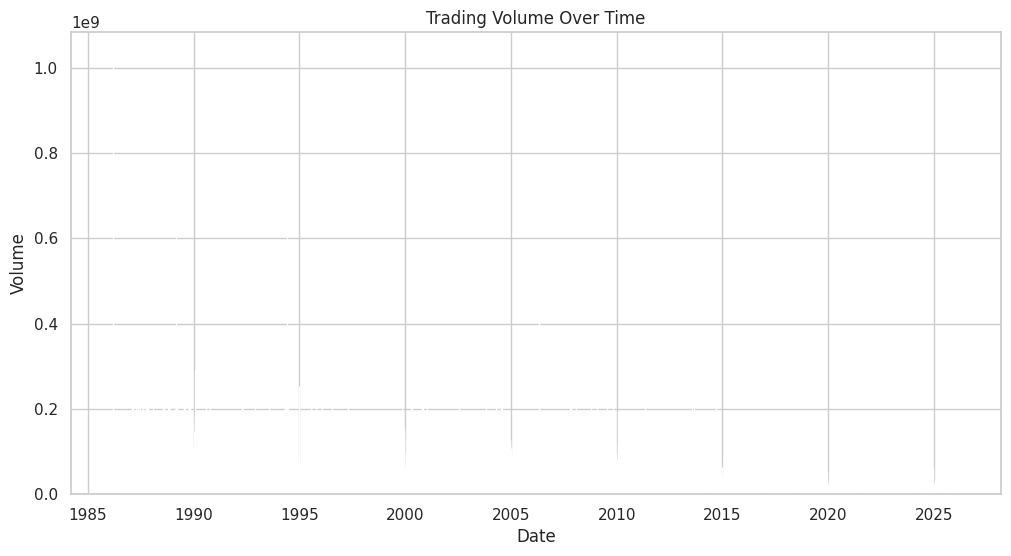

In [15]:
plt.figure(figsize=(12,6))
plt.bar(df['Date'], df['Volume'], color='purple')
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

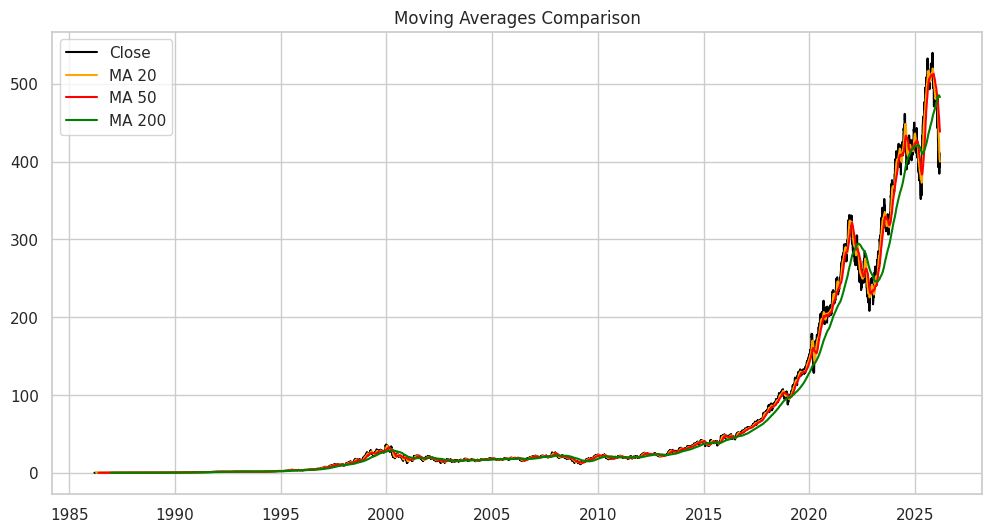

In [16]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label="Close", color="black")
plt.plot(df['Date'], df['MA_20'], label="MA 20", color="orange")
plt.plot(df['Date'], df['MA_50'], label="MA 50", color="red")
plt.plot(df['Date'], df['MA_200'], label="MA 200", color="green")
plt.legend()
plt.title("Moving Averages Comparison")
plt.show()

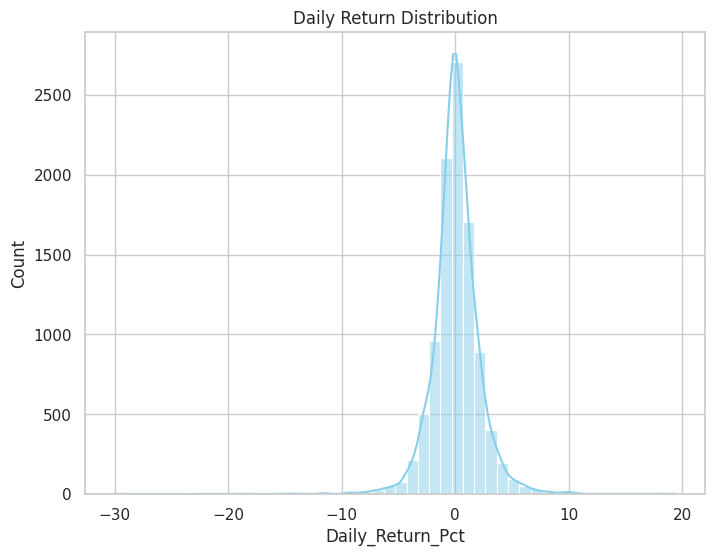

In [17]:
plt.figure(figsize=(8,6))
sns.histplot(df['Daily_Return_Pct'], bins=50, color='skyblue', kde=True)
plt.title("Daily Return Distribution")
plt.show()

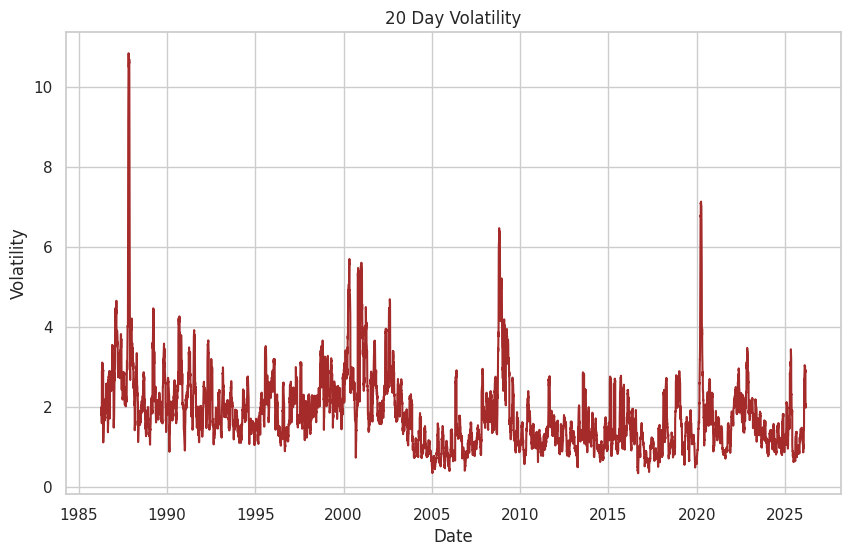

In [18]:
plt.figure(figsize=(10,6))
plt.plot(df['Date'], df['Volatility_20D'], color='brown')
plt.title("20 Day Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

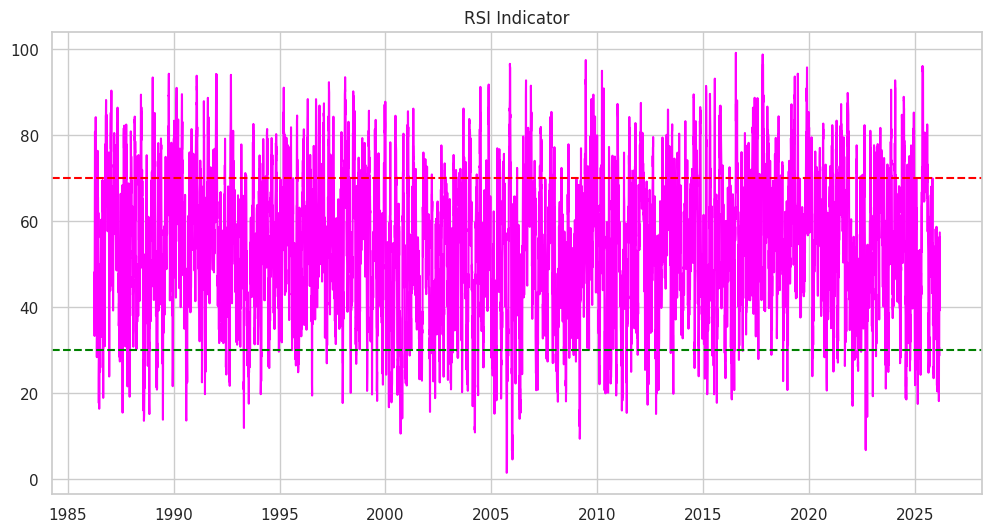

In [19]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['RSI_14'], color='magenta')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title("RSI Indicator")
plt.show()

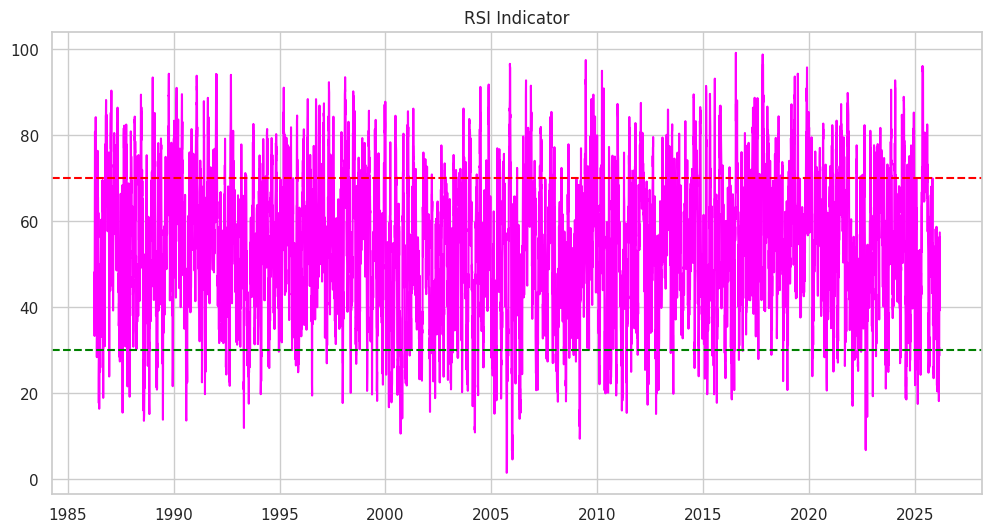

In [20]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['RSI_14'], color='magenta')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title("RSI Indicator")
plt.show()

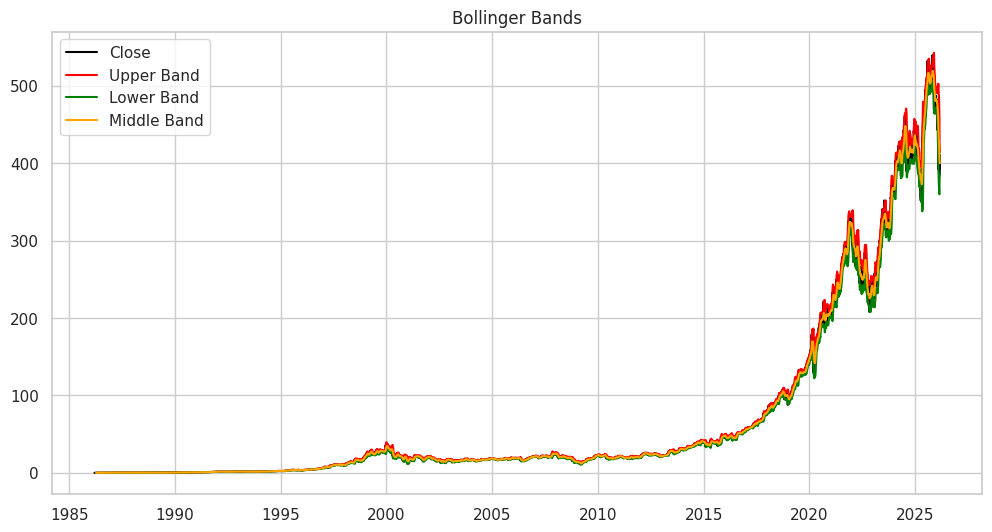

In [21]:
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label="Close", color="black")
plt.plot(df['Date'], df['BB_Upper'], label="Upper Band", color="red")
plt.plot(df['Date'], df['BB_Lower'], label="Lower Band", color="green")
plt.plot(df['Date'], df['BB_Middle'], label="Middle Band", color="orange")
plt.legend()
plt.title("Bollinger Bands")
plt.show()

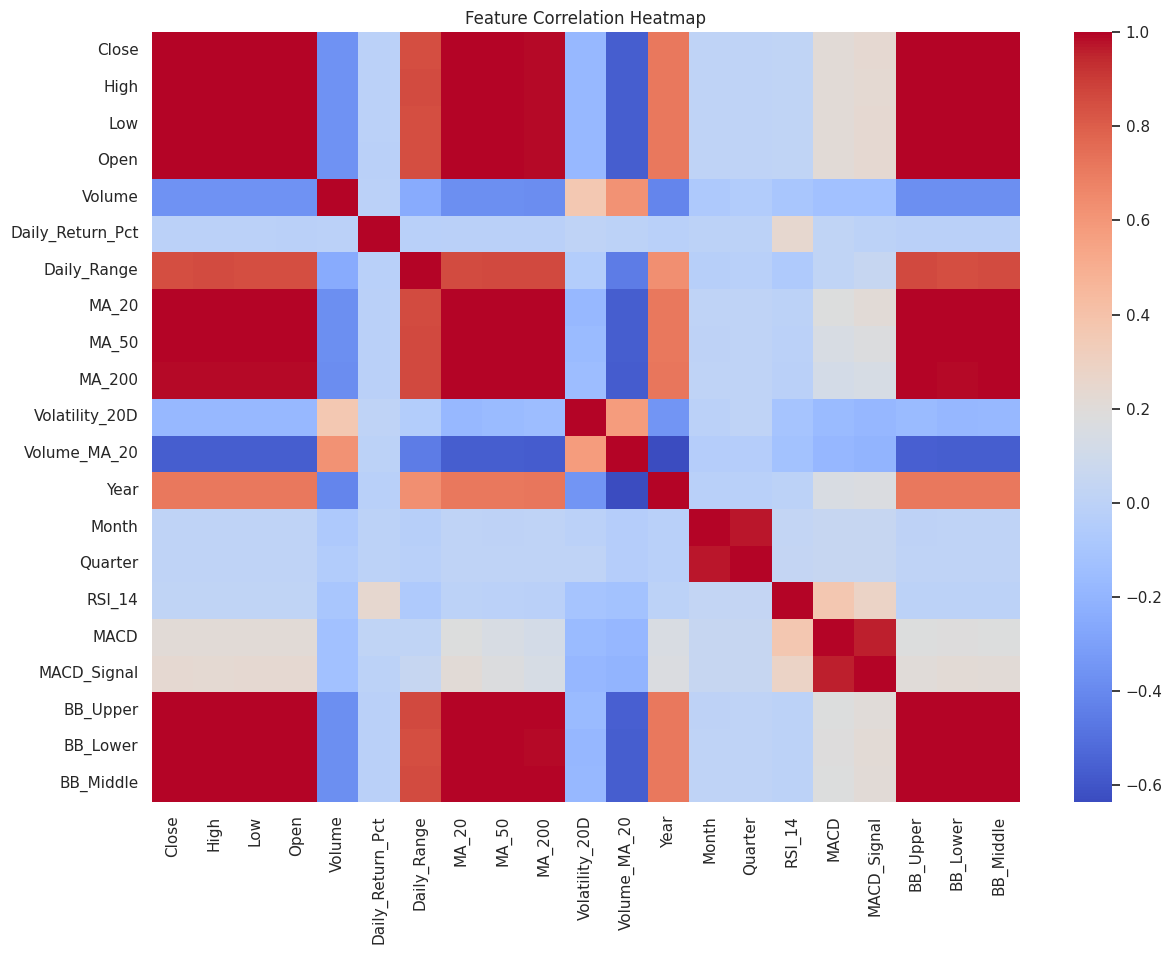

In [22]:
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

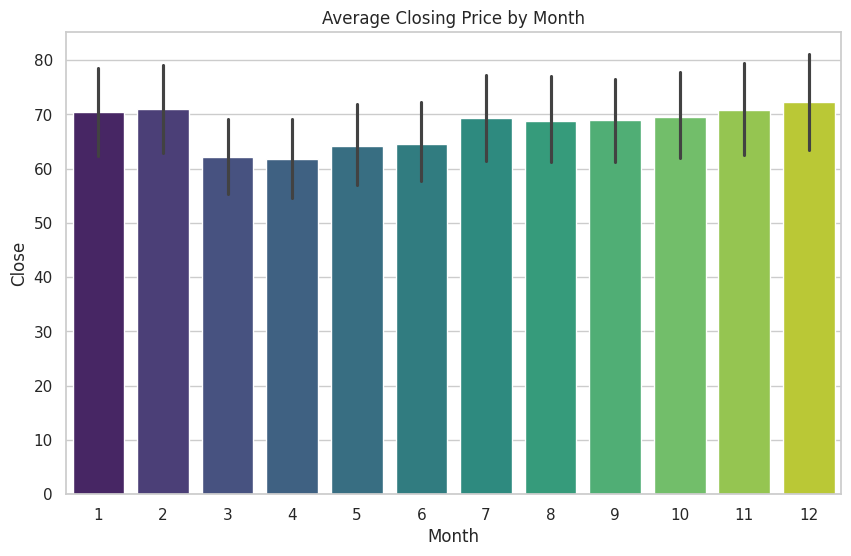

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(x="Month", y="Close", data=df, palette="viridis")
plt.title("Average Closing Price by Month")
plt.show()

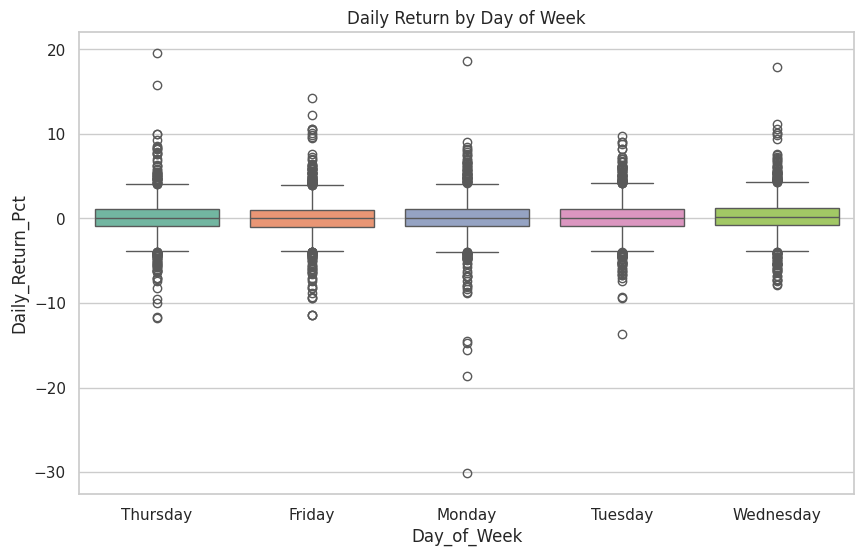

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Day_of_Week", y="Daily_Return_Pct", data=df, palette="Set2")
plt.title("Daily Return by Day of Week")
plt.show()

## feature engineering

In [25]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [27]:
df['Target'] = np.where(df['Daily_Return_Pct'] > 0, 1, 0)

In [28]:
X = df.drop(['Date','Target'], axis=1)
y = df['Target']

In [29]:
# Numeric columns
num_cols = X.select_dtypes(include=['int64','float64']).columns

# Categorical columns
cat_cols = X.select_dtypes(include=['object']).columns

# Fill numeric NaN with mean
X[num_cols] = X[num_cols].fillna(X[num_cols].mean())

# Fill categorical NaN with mode
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = X.select_dtypes(include='object').columns

for col in cat_cols:
    X[col] = le.fit_transform(X[col])

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}


MODEL: Logistic Regression
Accuracy: 99.70%


<Figure size 1000x800 with 0 Axes>

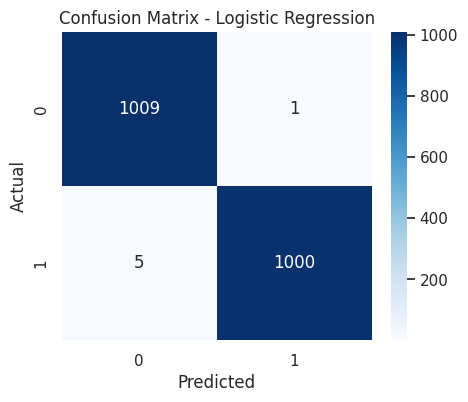


MODEL: Decision Tree
Accuracy: 99.95%


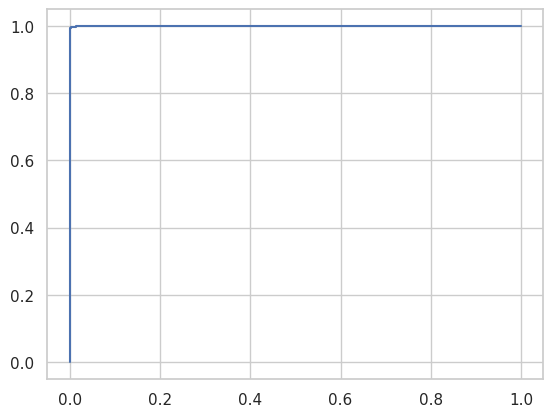

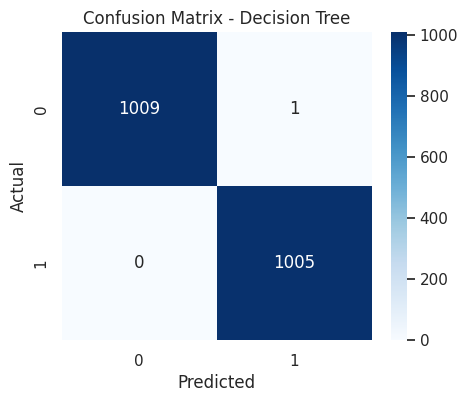


MODEL: Random Forest
Accuracy: 99.95%


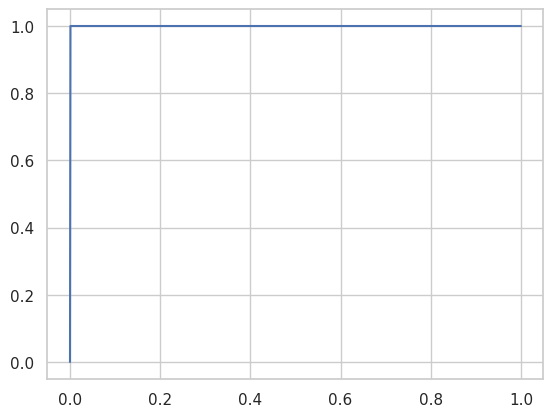

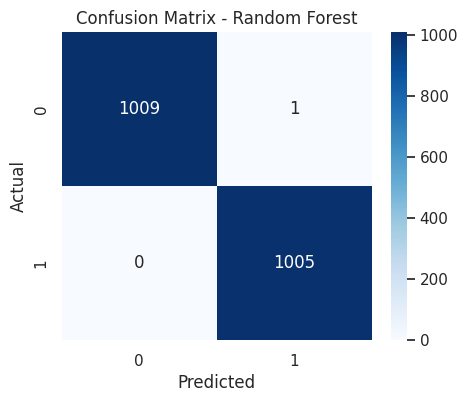


MODEL: SVM
Accuracy: 98.16%


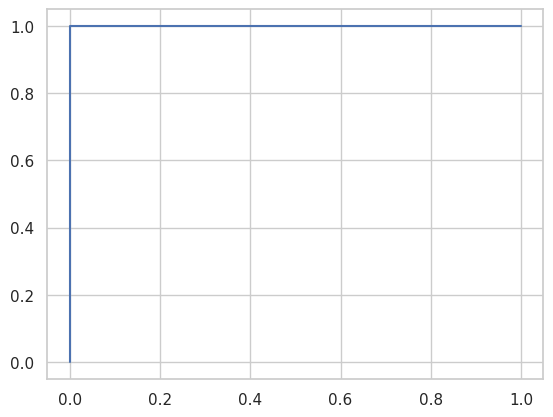

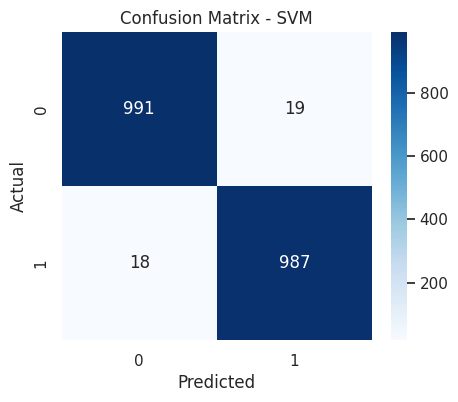


MODEL: KNN
Accuracy: 86.45%


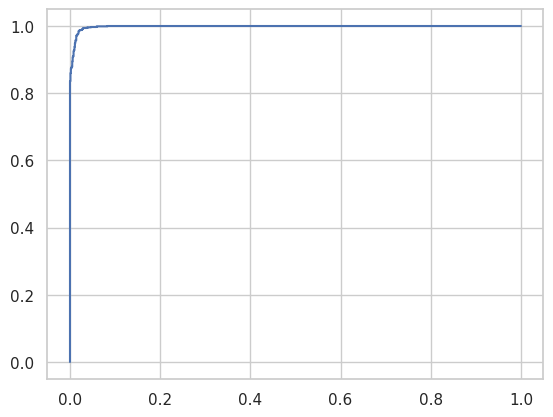

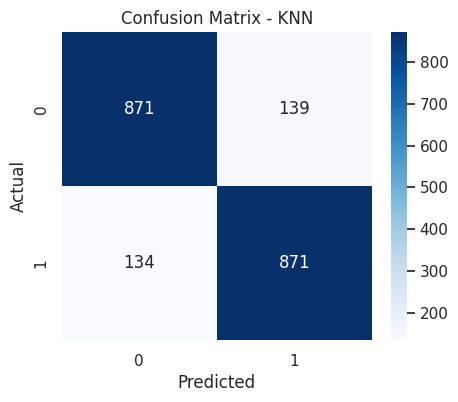


MODEL: Naive Bayes
Accuracy: 88.59%


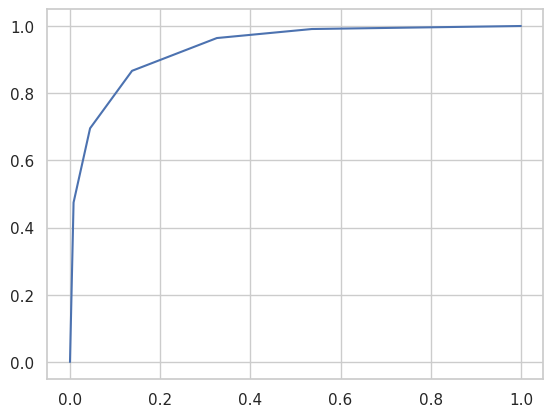

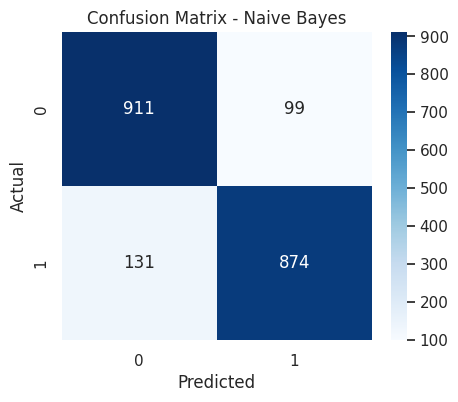

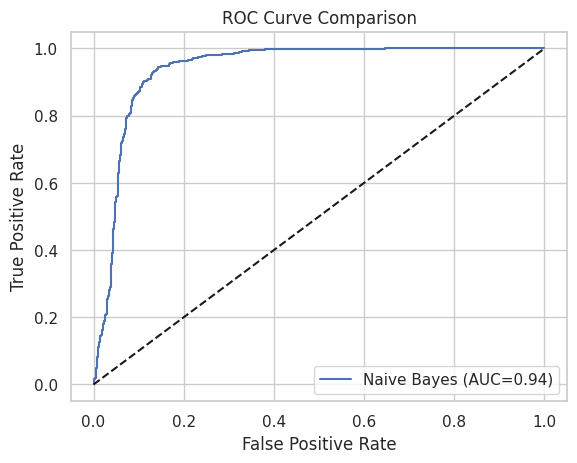

In [34]:
results = []

plt.figure(figsize=(10,8))

for name, model in models.items():
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred) * 100
    results.append((name, acc))
    
    print("\n==============================")
    print("MODEL:", name)
    print("Accuracy: {:.2f}%".format(acc))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # ROC Curve
    y_prob = model.predict_proba(X_test)[:,1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

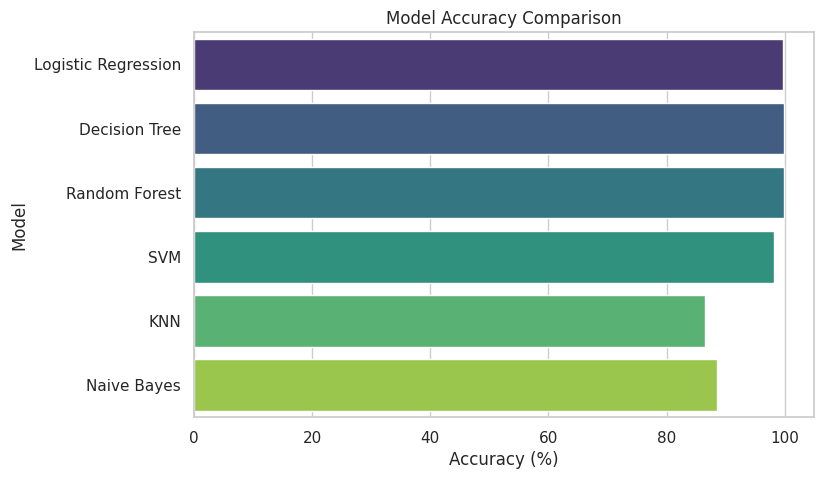

                 Model  Accuracy (%)
0  Logistic Regression     99.702233
1        Decision Tree     99.950372
2        Random Forest     99.950372
3                  SVM     98.163772
4                  KNN     86.451613
5          Naive Bayes     88.585608


In [35]:
results_df = pd.DataFrame(results, columns=["Model","Accuracy (%)"])

plt.figure(figsize=(8,5))
sns.barplot(x="Accuracy (%)", y="Model", data=results_df, palette="viridis")

plt.title("Model Accuracy Comparison")
plt.show()

print(results_df)

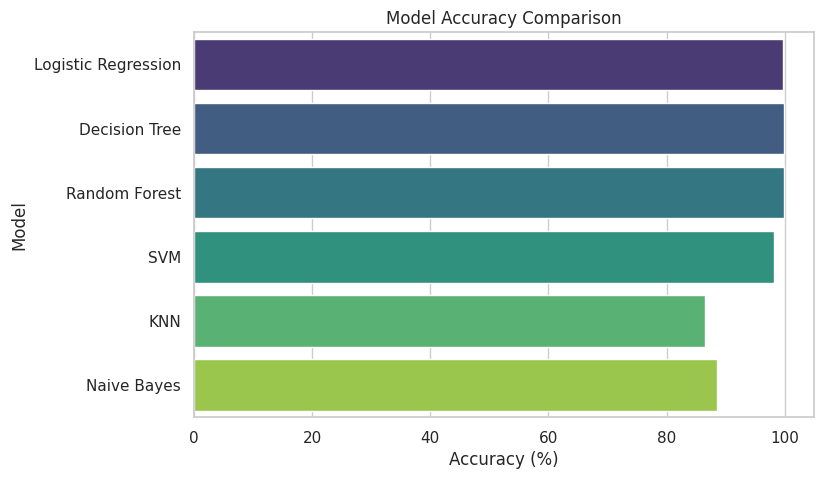

                 Model  Accuracy (%)
0  Logistic Regression     99.702233
1        Decision Tree     99.950372
2        Random Forest     99.950372
3                  SVM     98.163772
4                  KNN     86.451613
5          Naive Bayes     88.585608


In [36]:
results_df = pd.DataFrame(results, columns=["Model","Accuracy (%)"])

plt.figure(figsize=(8,5))
sns.barplot(x="Accuracy (%)", y="Model", data=results_df, palette="viridis")

plt.title("Model Accuracy Comparison")
plt.show()

print(results_df)

## Thank you..pls upvote!!!!!!